## Load In OWGR Data Via PDF

In [1]:
import pandas as pd
import re
import os
import json
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

def parse_owgr_pdf(pdf_path, date, top_n=200):
    """
    Parse OWGR PDF and return top N players as a DataFrame.
    """
    import pdfplumber
    rows = []
    # Known countries in the OWGR (including variations)
    countries = [
        'United States', 'England', 'Scotland', 'Ireland', 'Northern Ireland',
        'Australia', 'South Korea', 'Japan', 'Sweden', 'Canada', 'Spain',
        'France', 'Germany', 'Italy', 'South Africa', 'Belgium', 'Austria',
        'Norway', 'Denmark', 'Finland', 'New Zealand', 'Netherlands', 'Colombia',
        'Argentina', 'Venezuela', 'Chile', 'Mexico', 'China', 'Philippines',
        'Zimbabwe', 'Taiwan (Chinese Taipei)', 'Poland', 'Wales', 'Czech Republic',
        'Switzerland', 'India', 'Thailand', 'Singapore', 'Malaysia', 'Indonesia',
        'Hong Kong', 'Puerto Rico', 'Brazil', 'Portugal', 'Hungary', 'Greece',
        'Paraguay', 'Dominican Republic', 'Peru', 'Korea', 'Chinese Taipei',
        'Korea; Republic of', 'Republic of Korea'  # Added Korean variations
    ]
    # Sort by length descending so longer names match first (e.g., "Korea; Republic of" before "Korea")
    countries_sorted = sorted(countries, key=len, reverse=True)
    # Pattern to match the beginning (ranks) and end (numeric stats) of each row
    # Format: Rank (LastWeek) <EndYear> Name Country Average Total Played Lost Won Played
    # Note: Won column can be "-" or a number
    # Note: Country may run directly into Average number without space (e.g., "Korea; Republic of4.1608")
    pattern = re.compile(
        r'^(\d+)\s+'                           # This week rank
        r'\((\d+)\)\s+'                         # Last week rank in ()
        r'<(\d+)>\s+'                           # End year rank in <>
        r'(.+?)'                                # Name + Country (captured together, non-greedy)
        r'(\d+\.\d+)\s+'                        # Average points (no space required before)
        r'(\d+\.\d+)\s+'                        # Total points
        r'(\d+)\s+'                             # Events played (divisor)
        r'(-\d+\.\d+)\s+'                       # Points lost (always negative)
        r'(-|\d+\.\d+)\s+'                      # Points won (can be "-" or number)
        r'(\d+)$'                               # Events played (actual)
    )
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text()
            if not text:
                continue
            for line in text.split('\n'):
                line = line.strip()
                # Skip header/footer lines
                if not line or line.startswith('Week') or line.startswith('Ending') or \
                   line.startswith('Events') or line.startswith('This') or \
                   line.startswith('Min-') or line.startswith('World') or \
                   line.startswith('Ranking') or line.startswith('Page') or \
                   'January' in line or 'February' in line or 'March' in line:
                    continue
                match = pattern.match(line)
                if match:
                    rank = int(match.group(1))
                    if rank <= top_n:
                        name_country = match.group(4).strip()
                        # Find the country in the name_country string
                        # Country may run directly into the number, so check if it ends with country OR country+digit
                        player = name_country
                        country = ''
                        for c in countries_sorted:
                            if name_country.endswith(c):
                                player = name_country[:-len(c)].strip()
                                country = c
                                break
                            # Handle case where country runs into number (no space)
                            # e.g., "Tom Kim Korea; Republic of" captured as "Tom Kim Korea; Republic of"
                            # but in the regex, it might be captured with trailing chars
                        # Handle points won being "-"
                        points_won = match.group(9)
                        points_won = 0.0 if points_won == '-' else float(points_won)
                        rows.append({
                            'Rank': rank,
                            'Last_Week_Rank': int(match.group(2)),
                            'End_2025_Rank': int(match.group(3)),
                            'Player': player,
                            'Country': country,
                            'Avg_Points': float(match.group(5)),
                            'Total_Points': float(match.group(6)),
                            'Events_Divisor': int(match.group(7)),
                            'Points_Lost_2026': float(match.group(8)),
                            'Points_Won_2026': points_won,
                            'Events_Actual': int(match.group(10))
                        })
    df = pd.DataFrame(rows)
    df = df.drop_duplicates(subset=['Rank', 'Player']).sort_values('Rank').reset_index(drop=True)
    df['Date'] = date
    return df.head(top_n)\

def owgr_df_to_dict(df, date_str):
    """
    Convert OWGR DataFrame to nested dictionary format.
    """
    result = {}
    for _, row in df.iterrows():
        player = row['Player']
        result[player] = {
            date_str: {
                'Avg_Points': row['Avg_Points'],
                'Total_Points': row['Total_Points'],
                'Events_Divisor': row['Events_Divisor'],
                'Events_Actual': row['Events_Actual']
            }
        }
    return result

def add_owgr_to_dict(df, date_str, existing_dict=None,):
    """
    Add OWGR data to an existing dictionary (or create new one).
    """
    if existing_dict is None:
        existing_dict = {}
    for _, row in df.iterrows():
        player = row['Player']
        if player not in existing_dict:
            existing_dict[player] = {}
        existing_dict[player][date_str] = {
            'Avg_Points': row['Avg_Points'],
            'Total_Points': row['Total_Points'],
            'Events_Divisor': row['Events_Divisor'],
            'Events_Actual': row['Events_Actual']
        }
    return existing_dict

def get_owgr_date(file):
    """
    Extract date from OWGR filename dynamically.
    Filename format: owgrWWfYYYY.pdf (e.g., owgr04f2026.pdf)
    Returns the Saturday of that ISO week as YYYY-MM-DD string.
    """
    import re
    match = re.match(r'owgr(\d{2})f(\d{4})\.pdf', file)
    if not match:
        raise ValueError(f"Invalid OWGR filename format: {file}")
    week_num = int(match.group(1))
    year = int(match.group(2))
    # Get the Saturday of the given ISO week
    # ISO week 1 is the week containing January 4th
    # We use %G (ISO year) and %V (ISO week) to get Monday of that week, then add 5 days for Saturday
    monday_of_week = datetime.strptime(f'{year}-W{week_num:02d}-1', '%G-W%V-%u')
    saturday_of_week = monday_of_week + timedelta(days=5)
    return saturday_of_week.strftime('%Y-%m-%d')

def american_odds_to_implied_prob(american_odds):
    if american_odds > 0:
        return 100 / (american_odds + 100)
    else:
        return -american_odds / (-american_odds + 100)

last_updated_date = "2026-01-25"
folder_path = '/Users/holden.bridge/Desktop/golf-research/owgr_historical'
# Load in existing OWGR dict
if not os.path.exists(f'{folder_path}/owgr_dict.json'):
    owgr_dict = {}
else:
    with open(f'{folder_path}/owgr_dict.json', 'r') as f:
        owgr_dict = json.load(f)
# Load in existing OWGR dict
if not os.path.exists(f'{folder_path}/tournament_fields.json'):
    tournament_fields = {}
else:
    with open(f'{folder_path}/tournament_fields.json', 'r') as f:
        tournament_fields = json.load(f)
# Parse new OWGR data
for file in os.listdir(folder_path):
    if not file.endswith('.pdf'):
        continue
    owgr_df = parse_owgr_pdf(f'{folder_path}/{file}', date=last_updated_date, top_n=200)
    owgr_dict = add_owgr_to_dict(owgr_df, date_str=get_owgr_date(file), existing_dict=owgr_dict)
    print(f"Finished Loading {file}")
# Save new OWGR data
with open(f'{folder_path}/owgr_dict.json', 'w') as f:
    json.dump(owgr_dict, f, indent=2)

## Plot Player Performance Over Time

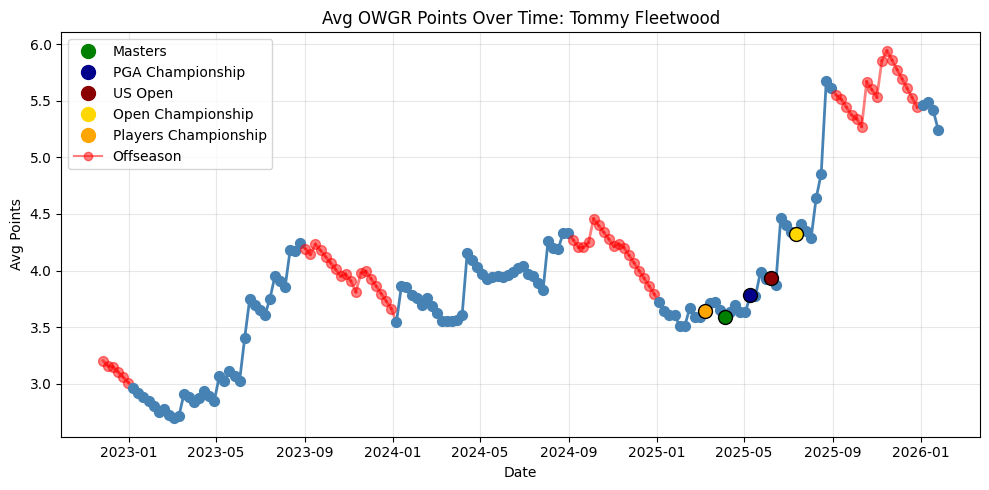

In [2]:
def plot_player_avg_points_over_time(player_name, owgr_dict):
    """
    Plot the Avg_Points of a given player over time.
    Marks "2025-08-09" with a green circle if present.
    Marks all points that occur in September through December in red with alpha=0.5 and labels this as 'offseason'.

    Args:
        player_name (str): Name of the player to plot.
        owgr_dict (dict): OWGR data dictionary.
    """
    players_start = "2025-03-08"
    masters_start = "2025-04-05"
    pga_championship_start = "2025-05-10"
    us_open_start = "2025-06-07"
    open_championship_start = "2025-07-12"

    if player_name not in owgr_dict:
        print(f"Player '{player_name}' not found in OWGR data.")
        return

    # Extract and sort data by date
    date_points = []
    for date, vals in owgr_dict[player_name].items():
        date_points.append((date, vals.get('Avg_Points', None)))
    # Sort by date
    date_points.sort(key=lambda x: x[0])
    dates = [d for d, v in date_points]
    avg_points = [v for d, v in date_points]

    # Convert dates for plotting
    dates_pd = pd.to_datetime(dates)

    plt.figure(figsize=(10, 5))
    
    # Determine which points are offseason (September through December)
    is_offseason = [date.month in [9, 10, 11, 12] for date in dates_pd]
    
    # Plot line segments with appropriate colors
    for i in range(len(dates_pd) - 1):
        # Use red if either endpoint is in offseason, otherwise blue
        if is_offseason[i] or is_offseason[i + 1]:
            color = 'red'
            alpha = 0.5
        else:
            color = 'steelblue'
            alpha = 1.0
        plt.plot(dates_pd[i:i+2], avg_points[i:i+2], color=color, alpha=alpha, linewidth=2)
    
    # Plot points with appropriate colors
    for i, (date, pts) in enumerate(zip(dates_pd, avg_points)):
        if is_offseason[i]:
            plt.scatter(date, pts, color='red', alpha=0.5, s=50, zorder=4)
        else:
            plt.scatter(date, pts, color='steelblue', s=50, zorder=4)

    # Mark special dates (FedExCup Playoffs and Masters) if present in the data
    label_added = set()
    if players_start in dates:
        idx = dates.index(players_start)
        plt.scatter(
            dates_pd[idx], avg_points[idx], color='orange', s=100,
            edgecolors='black', label='Players Championship', zorder=5
        )
    if masters_start in dates:
        idx = dates.index(masters_start)
        # Only set label if "Masters" isn't already added (would only both exist on same date if coincidentally identical dates)
        plt.scatter(
            dates_pd[idx], avg_points[idx], color='green', s=100,
            edgecolors='black', label='Masters', zorder=5
        )
    if pga_championship_start in dates:
        idx = dates.index(pga_championship_start)
        plt.scatter(
            dates_pd[idx], avg_points[idx], color='darkblue', s=100,
            edgecolors='black', label='PGA Championship', zorder=5
        )
    if us_open_start in dates:
        idx = dates.index(us_open_start)
        plt.scatter(
            dates_pd[idx], avg_points[idx], color='darkred', s=100,
            edgecolors='black', label='US Open', zorder=5
        )
    if open_championship_start in dates:
        idx = dates.index(open_championship_start)
        plt.scatter(
            dates_pd[idx], avg_points[idx], color='gold', s=100,
            edgecolors='black', label='Open Championship', zorder=5
        )
        
    # Create legend handles manually
    legend_elements = [       
        Line2D([0], [0], color='green', marker='o', markersize=10, linestyle='None', label='Masters'),
        Line2D([0], [0], color='darkblue', marker='o', markersize=10, linestyle='None', label='PGA Championship'),
        Line2D([0], [0], color='darkred', marker='o', markersize=10, linestyle='None', label='US Open'),
        Line2D([0], [0], color='gold', marker='o', markersize=10, linestyle='None', label='Open Championship'),
        Line2D([0], [0], color='orange', marker='o', markersize=10, linestyle='None', label='Players Championship'),
        Line2D([0], [0], color='red', marker='o', alpha=0.5, label='Offseason')
    ]
    plt.legend(handles=legend_elements)

    plt.title(f'Avg OWGR Points Over Time: {player_name}')
    plt.xlabel('Date')
    plt.ylabel('Avg Points')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_player_avg_points_over_time("Tommy Fleetwood", owgr_dict)

## Train A Prediction Model

In [3]:
def load_event_odds(event_name, folder_path):
    """Load odds JSON for an event and return a dict mapping PlayerName -> {WinOdds, T5Odds, T10Odds, T20Odds}."""
    odds_path = f'{folder_path}/{event_name}_odds.json'
    if not os.path.exists(odds_path):
        return {}
    with open(odds_path, 'r') as f:
        odds_data = json.load(f)

    def reformat(name):
        if isinstance(name, str) and ',' in name:
            last, first = [x.strip() for x in name.split(',', 1)]
            return f"{first} {last}"
        return name

    player_odds = {}
    for market_key, col_name in [('win_odds', 'WinOdds'), ('T5_odds', 'T5Odds'),
                                  ('T10_odds', 'T10Odds'), ('T20_odds', 'T20Odds')]:
        for entry in odds_data.get(market_key, []):
            pname = reformat(entry['player_name'])
            if pname not in player_odds:
                player_odds[pname] = {}
            player_odds[pname][col_name] = entry.get('close_odds', None)
    return player_odds

def evaluate_event(event_start_date, event_end_date, owgr_dict, event_name):
    weeks_before = range(1, 13)
    base_date = datetime.strptime(event_start_date, "%Y-%m-%d")
    week_dates = {}
    for w in weeks_before:
        target_date = base_date - timedelta(weeks=w)
        week_dates[f'Avg_Points_{w}weekbefore'] = target_date.strftime("%Y-%m-%d")

    player_odds = load_event_odds(event_name, folder_path)

    rows = []
    for player, data in owgr_dict.items():
        if player not in tournament_fields[event_name]:
            continue
        row = {'PlayerName': player}
        for colname, week_date in week_dates.items():
            row[colname] = data.get(week_date, {}).get('Avg_Points', None)
        row['Avg_Points_StartEvent'] = data.get(event_start_date, {}).get('Avg_Points', None)
        row['Avg_Points_EndEvent'] = data.get(event_end_date, {}).get('Avg_Points', None)
        if row['Avg_Points_StartEvent'] is not None:
            row['EventName'] = event_name
            row['FinishingPosition'] = tournament_fields[event_name][player]['Finishing Position']
            odds = player_odds.get(player, {})
            row['WinOdds'] = odds.get('WinOdds', None)
            row['T5Odds'] = odds.get('T5Odds', None)
            row['T10Odds'] = odds.get('T10Odds', None)
            row['T20Odds'] = odds.get('T20Odds', None)
            rows.append(row)

    return pd.DataFrame(rows)

# 2025 Season
df_players2025 = evaluate_event("2025-03-08", "2025-03-15", owgr_dict, "PlayersChampionship2025")
df_masters2025 = evaluate_event("2025-04-05", "2025-04-12", owgr_dict, "Masters2025")
df_PGA_Championship2025 = evaluate_event("2025-05-10", "2025-05-17", owgr_dict, "PGAChampionship2025")
df_US_Open2025 = evaluate_event("2025-06-07", "2025-06-14", owgr_dict, "USOpen2025")
df_Open_Championship2025 = evaluate_event("2025-07-12", "2025-07-19", owgr_dict, "OpenChampionship2025")

# 2024 Season
df_players2024 = evaluate_event("2024-03-09", "2024-03-16", owgr_dict, "PlayersChampionship2024")
df_masters2024 = evaluate_event("2024-04-06", "2024-04-13", owgr_dict, "Masters2024")
df_PGA_Championship2024 = evaluate_event("2024-05-11", "2024-05-18", owgr_dict, "PGAChampionship2024")
df_US_Open2024 = evaluate_event("2024-06-08", "2024-06-15", owgr_dict, "USOpen2024")
df_Open_Championship2024 = evaluate_event("2024-07-13", "2024-07-20", owgr_dict, "OpenChampionship2024")

# 2023 Season
df_players2023 = evaluate_event("2023-03-04", "2023-03-11", owgr_dict, "PlayersChampionship2023")
df_masters2023 = evaluate_event("2023-04-01", "2023-04-08", owgr_dict, "Masters2023")
df_PGA_Championship2023 = evaluate_event("2023-05-13", "2023-05-20", owgr_dict, "PGAChampionship2023")
df_US_Open2023 = evaluate_event("2023-06-10", "2023-06-17", owgr_dict, "USOpen2023")
df_Open_Championship2023 = evaluate_event("2023-07-15", "2023-07-22", owgr_dict, "OpenChampionship2023")

In [ ]:
df_players2025

In [4]:
def prepare_modeling_df(df):
    df_result = df.copy()
    df_result['EventChange'] = df_result['Avg_Points_EndEvent'] - df_result['Avg_Points_StartEvent']
    for i in range(1, 13):
        week_col = f'Avg_Points_{i}weekbefore'
        df_result[f'Week{i}Change'] = df_result['Avg_Points_StartEvent'] - df_result.get(week_col)
    # Also include Avg_Points_StartEvent and EventName in the resulting DataFrame
    df_result = df_result[[col for col in df_result.columns if ('Change' in col or col == 'PlayerName') or ('Odds' in col or col == 'PlayerName') or col == 'Avg_Points_StartEvent' or col == 'EventName' or col == 'FinishingPosition']]
    return df_result

df_modeling_players2025 = prepare_modeling_df(df_players2025)
df_modeling_masters2025 = prepare_modeling_df(df_masters2025)
df_modeling_pga_championship2025 = prepare_modeling_df(df_PGA_Championship2025)
df_modeling_us_open2025 = prepare_modeling_df(df_US_Open2025)
df_modeling_open_championship2025 = prepare_modeling_df(df_Open_Championship2025)

df_modeling_players2024 = prepare_modeling_df(df_players2024)
df_modeling_masters2024 = prepare_modeling_df(df_masters2024)
df_modeling_pga_championship2024 = prepare_modeling_df(df_PGA_Championship2024)
df_modeling_us_open2024 = prepare_modeling_df(df_US_Open2024)
df_modeling_open_championship2024 = prepare_modeling_df(df_Open_Championship2024)

df_modeling_players2023 = prepare_modeling_df(df_players2023)
df_modeling_masters2023 = prepare_modeling_df(df_masters2023)
df_modeling_pga_championship2023 = prepare_modeling_df(df_PGA_Championship2023)
df_modeling_us_open2023 = prepare_modeling_df(df_US_Open2023)
df_modeling_open_championship2023 = prepare_modeling_df(df_Open_Championship2023)

df_modeling = pd.concat([
df_modeling_players2023, df_modeling_masters2023, df_modeling_pga_championship2023, df_modeling_us_open2023, df_modeling_open_championship2023,
df_modeling_players2024, df_modeling_masters2024, df_modeling_pga_championship2024, df_modeling_us_open2024, df_modeling_open_championship2024,
])
feature_cols = [f'Week{i}Change' for i in [4, 8, 12]]
drop_cols = feature_cols + ['EventChange', 'WinOdds', 'T5Odds', 'T10Odds', 'T20Odds']
df_model_clean = df_modeling.dropna()
df_model_clean['GainPoints'] = (df_model_clean['EventChange'] > 0).astype(int)
df_model_clean['MadeT20'] = (df_model_clean['FinishingPosition'] <= 20).astype(int)
df_model_clean['WinProb'] = df_model_clean['WinOdds'].apply(american_odds_to_implied_prob)
df_model_clean['T5Prob'] = df_model_clean['T5Odds'].apply(american_odds_to_implied_prob)
df_model_clean['T10Prob'] = df_model_clean['T10Odds'].apply(american_odds_to_implied_prob)
df_model_clean['T20Prob'] = df_model_clean['T20Odds'].apply(american_odds_to_implied_prob)

TypeError: '>' not supported between instances of 'str' and 'int'

In [5]:
df_model_clean

,PlayerName,Avg_Points_StartEvent,EventName,FinishingPosition,WinOdds,T5Odds,T10Odds,T20Odds,EventChange,Week1Change,Week2Change,Week3Change,Week4Change,Week5Change,Week6Change,Week7Change,Week8Change,Week9Change,Week10Change,Week11Change,Week12Change,GainPoints,MadeT20
0,Scottie Scheffler,9.1841,PlayersChampionship2023,1,+1000,+240,+125,-170,1.2148,0.1534,0.1791,0.0032,1.1312,1.1393,0.9926,0.9584,0.8119,0.7769,0.6291,0.4813,0.3335,1,1
1,Rory McIlroy,9.0415,PlayersChampionship2023,999,+950,+240,+105,-180,-0.1451,0.5993,0.6377,0.3707,0.2806,0.3250,0.8154,0.6756,0.5357,0.3959,0.2581,0.1203,-0.0158,0,0
2,Tommy Fleetwood,2.6953,PlayersChampionship2023,27,+8500,+1500,+750,+290,0.0202,-0.0327,-0.0825,-0.0590,-0.1056,-0.1523,-0.1923,-0.2236,-0.2700,-0.3162,-0.3621,-0.4080,-0.4538,1,0
3,Xander Schauffele,5.8337,PlayersChampionship2023,19,+2700,+500,+280,+110,-0.1246,-0.0595,-0.0323,-0.2122,-0.1400,-0.1228,-0.2737,-0.1083,-0.0939,-0.3552,-0.4786,-0.6020,-0.7255,0,1
4,Russell Henley,2.2275,PlayersChampionship2023,19,+10000,+1400,+650,+360,0.0150,-0.0654,-0.0589,-0.1539,-0.1987,-0.2339,-0.2148,-0.1976,-0.2524,-0.3065,-0.3428,-0.3791,-0.4154,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Adrian Meronk,1.5282,OpenChampionship2024,50,+35000,+4500,+1600,+600,0.0159,0.0021,-0.0024,-0.0394,-0.0764,-0.1491,-0.1504,-0.1538,-0.1922,-0.2316,-0.2344,-0.2387,-0.2782,1,0
90,Yannik Paul,0.8474,OpenChampionship2024,999,+60000,+8000,+2800,+900,-0.0174,0.0408,0.0217,0.0027,-0.0148,-0.0323,-0.0445,-0.0460,-0.0639,-0.0817,-0.0996,-0.0823,-0.0878,0,0
92,Louis Oosthuizen,0.8294,OpenChampionship2024,999,+6500,+1100,+450,+200,-0.0128,-0.0128,-0.0256,-0.0394,-0.0532,-0.0670,-0.0808,-0.0946,-0.1088,-0.1206,-0.1323,-0.1440,-0.1557,0,0
93,Vincent Norrman,0.9263,OpenChampionship2024,999,+100000,+22000,+7000,+2000,-0.0176,-0.0174,-0.0341,-0.0505,-0.0669,-0.0832,-0.0930,-0.0985,-0.1036,-0.1223,-0.1389,-0.1572,-0.1739,0,0


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score)

class BinaryXGBClassifier:
    def __init__(
        self,
        X,
        y,
        param_grid,
        use_gpu=False,
        loss_func="accuracy",
        cv=5,
        random_state=33,
        eval_metric="auc",
    ):
        from sklearn.model_selection import train_test_split

        self.loss_func = loss_func
        self.cv = cv
        self.random_state = random_state
        self.eval_metric = eval_metric
        self.tree_method = "gpu_hist" if use_gpu else "hist"
        self.param_grid = param_grid

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=0.2, random_state=self.random_state
        )

    def fit(self):
        if self.eval_metric == "f1":
            model = XGBClassifier(
                random_state=self.random_state,
                eval_metric="auc",
                objective="binary:logistic",
                tree_method=self.tree_method,
            )
        else:
            model = XGBClassifier(
                random_state=self.random_state,
                eval_metric=self.eval_metric,
                objective="binary:logistic",
                tree_method=self.tree_method,
            )

        self.grid = GridSearchCV(
            model,
            self.param_grid,
            scoring=self.loss_func,
            cv=self.cv,
            verbose=1,
            n_jobs=-1,
        )
        self.grid.fit(self.X_train, self.y_train)

    def predict(self, X_test):
        return self.grid.predict(X_test)

    def predict_probs(self, X_test):
        return self.grid.predict_proba(X_test)

    def score(self, X_test, y_test):
        threshold = 0.5
        y_pred = self.predict_probs(X_test)
        y_pred = y_pred[:, 1]
        round_y_pred = (y_pred >= threshold).astype(int)
        acc = accuracy_score(y_test, round_y_pred)
        f1 = f1_score(y_test, round_y_pred)
        log_loss_score = log_loss(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred)
        precision = precision_score(y_test, round_y_pred)
        recall = recall_score(y_test, round_y_pred)
        balanced_acc = balanced_accuracy_score(y_test, round_y_pred)

        # print each metric with the title of the metric in all caps, and the score rounded to 2 decimal places
        print("THRESHOLD:", round(threshold, 2))
        print("ACCURACY:", round(acc, 2))
        print("F1 SCORE:", round(f1, 2))
        print("LOG LOSS:", round(log_loss_score, 2))
        print("ROC AUC:", round(roc_auc, 2))
        print("PRECISION:", round(precision, 2))
        print("RECALL:", round(recall, 2))
        print("BALANCED ACCURACY:", round(balanced_acc, 2))

        # return labeled dictionary of scores
        return {
            "accuracy": acc,
            "f1": f1,
            "log_loss": log_loss_score,
            "roc_auc": roc_auc,
            "precision": precision,
            "recall": recall,
            "balanced_accuracy": balanced_acc,
        }

    def plot_roc_auc_curve(self, X_test, y_test):
        from matplotlib import pyplot as plt
        from sklearn.metrics import roc_curve

        y_pred = self.predict_probs(X_test)
        y_pred = y_pred[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred)
        plt.plot(fpr, tpr, color="orange", label="ROC")
        plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("Receiver Operating Characteristic (ROC) Curve")
        plt.legend()
        plt.show()

    def plot_feature_importances(self, title="Feature Importances"):
        import matplotlib.pyplot as plt
        from numpy import argsort

        # plot feature importances from most important to least important
        # and the x labels are the names of the features
        plt.figure(figsize=(15, 15))
        plt.title(title)
        features = self.X_train.columns
        importances = self.grid.best_estimator_.feature_importances_
        indices = argsort(importances)
        plt.barh(range(len(indices)), importances[indices], color="b", align="center")
        plt.yticks(range(len(indices)), [features[i] for i in indices])
        plt.xlabel("Relative Importance")
        plt.show()

    def run(self):
        # this function should fit the model and return a tuple of (fitted final model, score, best params)
        self.fit()
        self.plot_feature_importances()
        self.plot_roc_auc_curve(self.X_test, self.y_test)
        scores = self.score(self.X_test, self.y_test)
        return self.grid.best_estimator_, scores, self.grid.best_params_

In [ ]:
from scipy.stats import linregress

def calc_slope(row):
    weeks = [row[f'Week{i}Change'] for i in range(1, 13)]
    slope, _, _, _, _ = linregress(range(12), weeks)
    return slope

df_model_clean['momentum_slope'] = df_model_clean.apply(calc_slope, axis=1)

# 2. Recent vs distant momentum
df_model_clean['recent_momentum'] = df_model_clean[['Week1Change', 'Week2Change', 'Week3Change', 'Week4Change']].mean(axis=1)
df_model_clean['distant_momentum'] = df_model_clean[['Week9Change', 'Week10Change', 'Week11Change', 'Week12Change']].mean(axis=1)
df_model_clean['recent_vs_distant'] = df_model_clean['recent_momentum'] - df_model_clean['distant_momentum']

# 3. Consistency (low std = steady performer)
df_model_clean['momentum_volatility'] = df_model_clean[[f'Week{i}Change' for i in range(1, 13)]].std(axis=1)

# 4. Best/worst week in window
df_model_clean['best_week'] = df_model_clean[[f'Week{i}Change' for i in range(1, 13)]].max(axis=1)
df_model_clean['worst_week'] = df_model_clean[[f'Week{i}Change' for i in range(1, 13)]].min(axis=1)
df_model_clean['week_range'] = df_model_clean['best_week'] - df_model_clean['worst_week']

# 5. Count of positive weeks (streak indicator)
df_model_clean['positive_week_count'] = (df_model_clean[[f'Week{i}Change' for i in range(1, 13)]] > 0).sum(axis=1)

# 6. Recent streak - consecutive positive weeks from most recent
def recent_streak(row):
    streak = 0
    for i in range(1, 13):
        if row[f'Week{i}Change'] > 0:
            streak += 1
        else:
            break
    return streak

df_model_clean['recent_positive_streak'] = df_model_clean.apply(recent_streak, axis=1)

df_model_clean['acceleration_4v12'] = df_model_clean['Week4Change'] - df_model_clean['Week12Change']
df_model_clean['points_x_momentum8'] = df_model_clean['Avg_Points_StartEvent'] * df_model_clean['Week8Change']

In [ ]:
from imblearn.over_sampling import SMOTE

# Create predictors and target variable
X = df_model_clean[['Avg_Points_StartEvent', 'Week4Change', 'recent_vs_distant', 'recent_positive_streak', 'acceleration_4v12', 'points_x_momentum8', 'WinProb', 'T20Prob']]
y = df_model_clean['MadeT20']

# Oversample minority class to match majority
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Original: {len(y)} samples ({y.sum()} positive)")
print(f"Resampled: {len(y_resampled)} samples ({y_resampled.sum()} positive)")

# Train model with resampled data
grid = {
    'max_depth': [5, 6, 7, 8, 10, 12],
    'learning_rate': [0.1, 0.2],
    'n_estimators': [75, 100, 175, 250],
    'min_child_weight': [10],
    'gamma': [1, 2]
}

model = BinaryXGBClassifier(X=X_resampled, y=y_resampled, param_grid=grid, cv=3).run()
xgb_model = model[0]

## Evaluate Model Performance

In [ ]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Summary plot - global feature importance with direction
shap.summary_plot(shap_values, X)

In [ ]:
df_modeling_testing = pd.concat([df_modeling_players2025, df_modeling_masters2025, df_modeling_pga_championship2025, df_modeling_us_open2025, df_modeling_open_championship2025])
df_modeling_testing.dropna(inplace=True)
df_modeling_testing['GainPoints'] = (df_modeling_testing['EventChange'] > 0).astype(int)
df_modeling_testing['MadeT20'] = (df_modeling_testing['FinishingPosition'] <= 20).astype(int)
df_modeling_testing['WinProb'] = df_modeling_testing['WinOdds'].apply(american_odds_to_implied_prob)
df_modeling_testing['T5Prob'] = df_modeling_testing['T5Odds'].apply(american_odds_to_implied_prob)
df_modeling_testing['T10Prob'] = df_modeling_testing['T10Odds'].apply(american_odds_to_implied_prob)
df_modeling_testing['T20Prob'] = df_modeling_testing['T20Odds'].apply(american_odds_to_implied_prob)

df_modeling_testing['recent_momentum'] = df_modeling_testing[['Week1Change', 'Week2Change', 'Week3Change', 'Week4Change']].mean(axis=1)
df_modeling_testing['distant_momentum'] = df_modeling_testing[['Week9Change', 'Week10Change', 'Week11Change', 'Week12Change']].mean(axis=1)
df_modeling_testing['recent_vs_distant'] = df_modeling_testing['recent_momentum'] - df_modeling_testing['distant_momentum']

df_modeling_testing['recent_positive_streak'] = df_modeling_testing.apply(recent_streak, axis=1)

df_modeling_testing['acceleration_4v12'] = df_modeling_testing['Week4Change'] - df_modeling_testing['Week12Change']
df_modeling_testing['points_x_momentum8'] = df_modeling_testing['Avg_Points_StartEvent'] * df_modeling_testing['Week8Change']

df_all_data = pd.concat([df_model_clean, df_modeling_testing])

df_modeling_testing['ModelPrediction'] = xgb_model.predict_proba(df_modeling_testing[['Avg_Points_StartEvent', 'Week4Change', 'recent_vs_distant', 'recent_positive_streak', 'acceleration_4v12', 'points_x_momentum8', 'WinProb', 'T20Prob']])[:, 1]

In [ ]:
df_modeling_testing

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Bin ModelPrediction by 0.1
bin_edges = np.arange(0, 1.05, 0.05)
df_modeling_testing['prob_bin'] = pd.cut(df_modeling_testing['ModelPrediction'], bins=bin_edges, include_lowest=True)

# Calculate the average GainPoints rate for each bin
calibration = df_modeling_testing.groupby('prob_bin').agg(
    avg_pred=('ModelPrediction', 'mean'),
    t20_rate=('MadeT20', 'mean'),
    count=('MadeT20', 'size')
).reset_index()

# Plot, size of point represents the number in that group
plt.figure(figsize=(8, 6))
sizes = calibration['count'] * 2  # Adjust multiplier for clarity; change if needed

plt.scatter(calibration['avg_pred'], calibration['t20_rate'], s=sizes, alpha=0.7, label='Calibration (size=count)', c='b', edgecolors='k')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfectly Calibrated')
plt.axhline(0.5, color='green', linestyle='--')
plt.xlabel('Average Predicted Probability')
plt.ylabel('Empirical T20 Rate')
plt.title('Calibration Plot: ModelPrediction vs. MadeT20')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Bin ModelPrediction by 0.1
bin_edges = np.arange(0, 1.1, 0.1)
df_modeling_testing['prob_bin'] = pd.cut(df_modeling_testing['ModelPrediction'], bins=bin_edges, include_lowest=True)

# Calculate the average GainPoints rate for each bin
calibration = df_modeling_testing.groupby('prob_bin').agg(
    avg_pred=('ModelPrediction', 'mean'),
    gainpoints_rate=('GainPoints', 'mean'),
    count=('GainPoints', 'size')
).reset_index()

# Plot, size of point represents the number in that group
plt.figure(figsize=(8, 6))
sizes = calibration['count'] * 2  # Adjust multiplier for clarity; change if needed

plt.scatter(calibration['avg_pred'], calibration['gainpoints_rate'], s=sizes, alpha=0.7, label='Calibration (size=count)', c='b', edgecolors='k')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Perfectly Calibrated')
plt.axhline(0.5, color='green', linestyle='--')
plt.xlabel('Average Predicted Probability')
plt.ylabel('Empirical GainPoints Rate')
plt.title('Calibration Plot: ModelPrediction vs. GainPoints')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# First, let's filter out invalid finishing positions (999 = missed cut/withdrawn)
df_valid = df_all_data[df_all_data['FinishingPosition'] != 999].copy()

# Define point bins for analysis
# Since the labels must be one fewer than bin edges, either add another bin edge or remove a label
# We'll add np.inf to handle '10+' as the upper bin
point_bins = [0, 1, 1.5, 2, 2.5, 3, 4, 8, 20]
point_labels = ['0-1', '1-1.5', '1.5-2', '2-2.5', '2.5-3', '3-4', '4-8', '8+']
df_valid['PointsBin'] = pd.cut(df_valid['Avg_Points_StartEvent'], bins=point_bins, labels=point_labels, right=False, include_lowest=True)

# 1. For each starting points range, find the average finishing position that results in GainPoints=1
gain_analysis = df_valid.groupby('PointsBin').apply(
    lambda x: pd.Series({
        'n_players': len(x),
        'n_gained': x['GainPoints'].sum(),
        'gain_rate': round(x['GainPoints'].mean(), 2),
        'avg_finish_when_gained': round(x[x['GainPoints']==1]['FinishingPosition'].mean(), 1),
        'avg_finish_when_lost': round(x[x['GainPoints']==0]['FinishingPosition'].mean(), 1),
        'median_finish_when_gained': x[x['GainPoints']==1]['FinishingPosition'].median(),
        'max_finish_when_gained': x[x['GainPoints']==1]['FinishingPosition'].max(),
        'min_finish_when_lost': x[x['GainPoints']==0]['FinishingPosition'].min(),
    })
).reset_index()

print("=" * 60)
print("Finishing Position Needed to Gain Points by Starting Points")
print("=" * 60)
print(gain_analysis.to_string(index=False))

# 2. Find the "breakeven" finishing position for each points range
print("\n" + "=" * 60)
print("ESTIMATED BREAKEVEN FINISHING POSITIONS BY STARTING POINTS")
print("=" * 60)

print(f"Players With Less Than 4 Starting Points -> MAKE CUT")
print(f"Players With More Than 4-8 Starting Points -> T20")
print(f"Players With More Than 8 Starting Points -> T10")



## Predict The Next Event

In [ ]:
# Convert player_name "Last, First" to "First Last" format
def reformat_player_name(name):
    if isinstance(name, str) and ',' in name:
        last, first = [x.strip() for x in name.split(',', 1)]
        return f"{first} {last}"
    return name

def get_event_odds(event_name, odds_type):
    # Load in existing OWGR dict
    if not os.path.exists(f'{folder_path}/{event_name}_odds.json'):
        event_odds = {}
    else:
        with open(f'{folder_path}/{event_name}_odds.json', 'r') as f:
            event_odds = json.load(f)

    event_odds_df = pd.DataFrame(event_odds[f'{odds_type}_odds'])

    event_odds_df['player_name'] = event_odds_df['player_name'].apply(reformat_player_name)
    event_odds_df.rename(columns={'player_name': 'PlayerName'}, inplace=True)
    return event_odds_df[['PlayerName', 'close_odds']]

def view_event_predictions(event_name):
    df_event = df_modeling_testing[df_modeling_testing['EventName'] == event_name]

    event_odds_df_cut = get_event_odds(event_name, 'cut')
    event_odds_df_cut.rename(columns={'close_odds': 'CutOdds'}, inplace=True)
    df_event = df_event.merge(event_odds_df_cut, on='PlayerName', how='inner')
    df_event['WinMoney'] = df_event.apply(
        lambda row: american_odds_payout(row['WinOdds']) if row['FinishingPosition'] == 1 else -1,
        axis=1
    )
    df_event['T5Money'] = df_event.apply(
        lambda row: american_odds_payout(row['T5Odds']) * 2 if row['FinishingPosition'] <= 5 else -2,
        axis=1
    )
    df_event['T10Money'] = df_event.apply(
        lambda row: american_odds_payout(row['T10Odds']) * 3 if row['FinishingPosition'] <= 10 else -3,
        axis=1
    )
    df_event['T20Money'] = df_event.apply(
        lambda row: american_odds_payout(row['T20Odds']) * 4 if row['FinishingPosition'] <= 20 else -4,
        axis=1
    )
    df_event['CutMoney'] = df_event.apply(
        lambda row: american_odds_payout(row['CutOdds']) * 5 if row['FinishingPosition'] < 100 else -5,
        axis=1
    )
    df_event['TotalProfit'] = df_event['WinMoney'] + df_event['T5Money'] + df_event['T10Money'] + df_event['T20Money'] + df_event['CutMoney']
    return df_event[['PlayerName', 'Avg_Points_StartEvent', 'EventChange', 'ModelPrediction', 'GainPoints', 'FinishingPosition', 'WinOdds', 'T5Odds', 'T10Odds', 'T20Odds', 'CutOdds', 'WinMoney', 'T5Money', 'T10Money', 'T20Money', 'CutMoney', 'TotalProfit']]

def american_odds_payout(odds_str):
    odds = int(odds_str.replace('+', ''))
    if odds > 0:
        return round(odds / 100, 2)
    else:
        return round(100 / abs(odds), 2)

total_profit = 0
random_profit = 0
for event in ['PlayersChampionship2025', 'Masters2025', 'PGAChampionship2025', 'USOpen2025', 'OpenChampionship2025']:
    df_event = view_event_predictions(event)

    # df_event = df_event[df_event['ModelPrediction'] <= 0.70]
   
    top_5 = df_event.sort_values(by='ModelPrediction', ascending=False).head(5)
    total_profit += top_5['TotalProfit'].sum()
    random_profit += (df_event['TotalProfit'].sum() / len(df_event)) * 5
    top_10 = df_event.sort_values(by='ModelPrediction', ascending=False).head(10)
    bottom_10 = df_event.sort_values(by='ModelPrediction', ascending=True).head(10)
    print(f"{event} Top 5 Players Total Profit: {round(top_5['TotalProfit'].sum(), 2)} | Random 5 Players Total Profit: {round((df_event['TotalProfit'].sum() / len(df_event)) * 5, 2)}")
    # print(f"{event} Top 10 Players Total Profit: {round(top_10['TotalProfit'].sum(), 2)}")
    # print(f"{event} Bottom 10 Players Total Profit: {round(bottom_10['TotalProfit'].sum(), 2)}")
    print(" ")

print(f"Total Profit: {round(total_profit, 2)} | Random Profit: {round(random_profit, 2)}")

In [ ]:
events = ['PlayersChampionship2025', 'Masters2025', 'PGAChampionship2025', 'USOpen2025', 'OpenChampionship2025']

total_value_profit = 0
total_random_profit = 0

for event in events:
    df_event = view_event_predictions(event)
    
    # Convert odds to implied probabilities
    for market in ['Win', 'T5', 'T10', 'T20', 'Cut']:
        df_event[f'{market}_ImpliedProb'] = df_event[f'{market}Odds'].apply(american_odds_to_implied_prob)
    
    # Value = model prediction minus implied probability
    for market in ['Win', 'T5', 'T10', 'T20', 'Cut']:
        df_event[f'{market}_Value'] = df_event['ModelPrediction'] - df_event[f'{market}_ImpliedProb']
    
    # Value picks: in calibrated sweet spot AND model sees them as undervalued vs T20 market
    value_picks = df_event[
        (df_event['T20_Value'] > 0)
    ].sort_values('T20_Value', ascending=False).head(5)
    
    random_ev = df_event['TotalProfit'].mean() * len(value_picks)
    event_profit = round(value_picks['TotalProfit'].sum(), 2)
    total_value_profit += event_profit
    total_random_profit += random_ev
    
    print(f"=== {event} ===")
    print(f"Value Picks ({len(value_picks)} players):")
    for _, row in value_picks.iterrows():
        marker = "✓" if row['GainPoints'] == 1 else "✗"
        print(f"  {marker} {row['PlayerName']:<25} Model: {row['ModelPrediction']:.3f}  T20 Implied: {row['T20_ImpliedProb']:.3f}  T20 Value: {row['T20_Value']:.3f}  Profit: {row['TotalProfit']:.2f}")
    print(f"Event Profit: {event_profit}  |  Random {len(value_picks)} Players EV: {round(random_ev, 2)}")
    print()

print(f"{'='*50}")
print(f"TOTAL Value Picks Profit: {round(total_value_profit, 2)}")
print(f"TOTAL Random Equivalent EV: {round(total_random_profit, 2)}")
print(f"Edge vs Random: {round(total_value_profit - total_random_profit, 2)}")

In [ ]:
### TODO -> try filtering data set to under a certain points threshold and see if that improves results (better suited to long shots) or adding interactuib terms 
### TODO -> dynamic setup for next event (we now require T20 Odds in order to calcultate "value" players)

In [ ]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0], 
                                      base_values=explainer.expected_value,
                                      data=X.iloc[0]))